In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

In [17]:
df = pd.read_csv('201902-fordgobike-tripdata .csv')
df.shape

(183412, 16)

In [18]:
station_cols = ['start_station_id', 'start_station_name', 'start_station_latitude', 'start_station_longitude',
                'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_longitude']
df[station_cols].isnull().sum()

start_station_id           197
start_station_name         197
start_station_latitude       0
start_station_longitude      0
end_station_id             197
end_station_name           197
end_station_latitude         0
end_station_longitude        0
dtype: int64

In [19]:
df_stations = df.dropna(subset=['start_station_name', 'end_station_name']).copy()
print('Rows before:', len(df), '| Rows after dropping missing station rows:', len(df_stations))

Rows before: 183412 | Rows after dropping missing station rows: 183215


## Top 10 Start Stations

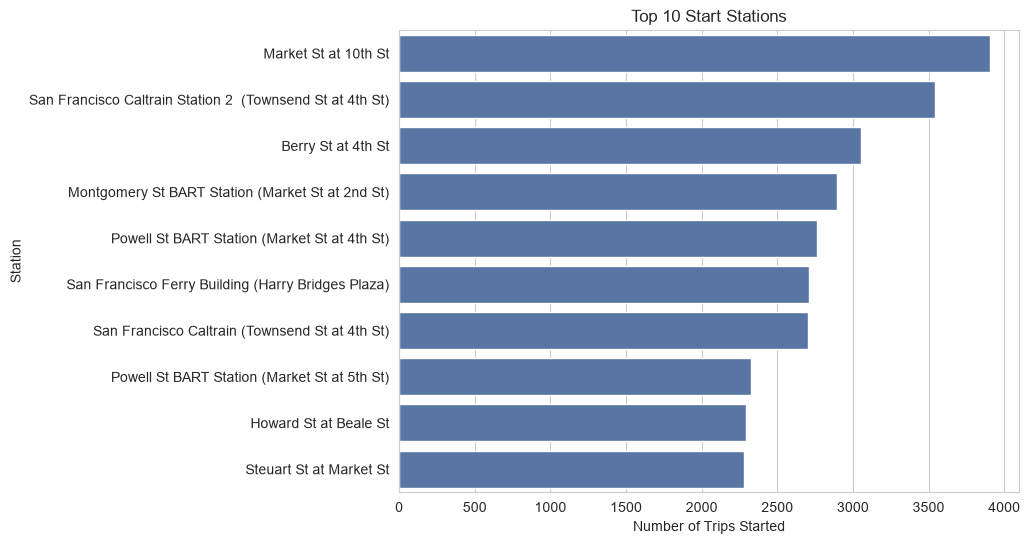

,Station,Trips
Rank,,
1,Market St at 10th St,3904
2,San Francisco Caltrain Station 2 (Townsend St...,3544
3,Berry St at 4th St,3052
4,Montgomery St BART Station (Market St at 2nd St),2895
5,Powell St BART Station (Market St at 4th St),2760
6,San Francisco Ferry Building (Harry Bridges Pl...,2710
7,San Francisco Caltrain (Townsend St at 4th St),2703
8,Powell St BART Station (Market St at 5th St),2327
9,Howard St at Beale St,2293


In [20]:
top_start = df_stations['start_station_name'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_start.values, y=top_start.index, orient='h', color='#4C72B0')
plt.title('Top 10 Start Stations')
plt.xlabel('Number of Trips Started')
plt.ylabel('Station')
plt.show()

top_start_table = top_start.reset_index()
top_start_table.columns = ['Station', 'Trips']
top_start_table.index = range(1, 11)
top_start_table.index.name = 'Rank'
top_start_table

**Insight:** "Market St at 10th St" is the single busiest starting point (3,904 trips), followed closely by "San Francisco Caltrain Station 2 (Townsend St at 4th St)" (3,544 trips). These top 10 start stations together account for **~15.5%** of all trips . The high usage of transit-related stations, such as Caltrain and BART stations, suggests that these locations play an important role in the bike-sharing network.

##  Top 10 End Stations

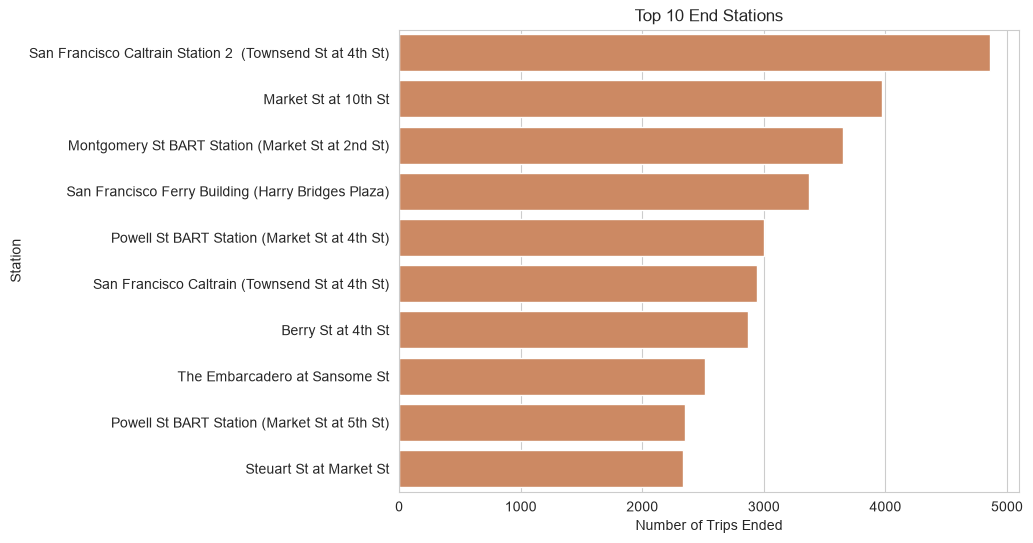

,Station,Trips
Rank,,
1,San Francisco Caltrain Station 2 (Townsend St...,4857
2,Market St at 10th St,3973
3,Montgomery St BART Station (Market St at 2nd St),3647
4,San Francisco Ferry Building (Harry Bridges Pl...,3368
5,Powell St BART Station (Market St at 4th St),2997
6,San Francisco Caltrain (Townsend St at 4th St),2947
7,Berry St at 4th St,2872
8,The Embarcadero at Sansome St,2512
9,Powell St BART Station (Market St at 5th St),2353


In [21]:
top_end = df_stations['end_station_name'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_end.values, y=top_end.index, orient='h', color='#DD8452')
plt.title('Top 10 End Stations')
plt.xlabel('Number of Trips Ended')
plt.ylabel('Station')
plt.show()

top_end_table = top_end.reset_index()
top_end_table.columns = ['Station', 'Trips']
top_end_table.index = range(1, 11)
top_end_table.index.name = 'Rank'
top_end_table

**Insight:** "San Francisco Caltrain Station 2" has more trips ending there (4,857) than trips starting there (3,544 as a start station), making it a particularly important destination within the network. This may indicate its importance as a transportation hub. The top 10 end stations cover **~17.4%** of all trips , slightly more concentrated than the start stations.

## Top 10 Routes (Start → End)

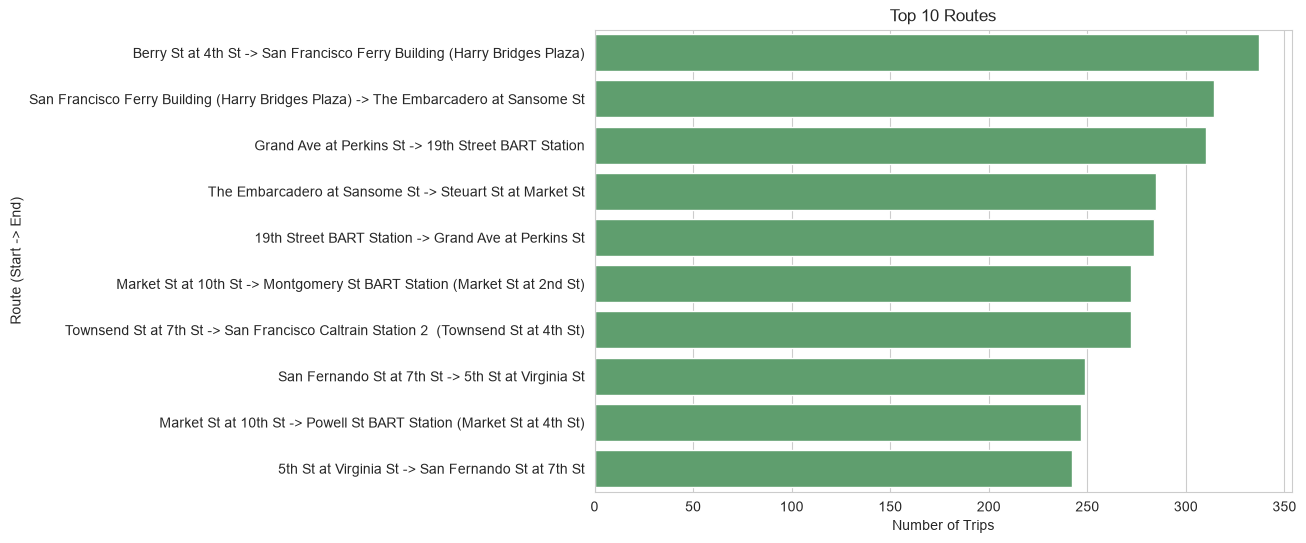

,Start Station,End Station,Trips
Rank,,,
1,Berry St at 4th St,San Francisco Ferry Building (Harry Bridges Pl...,337
2,San Francisco Ferry Building (Harry Bridges Pl...,The Embarcadero at Sansome St,314
3,Grand Ave at Perkins St,19th Street BART Station,310
4,The Embarcadero at Sansome St,Steuart St at Market St,285
5,19th Street BART Station,Grand Ave at Perkins St,284
6,Market St at 10th St,Montgomery St BART Station (Market St at 2nd St),272
7,Townsend St at 7th St,San Francisco Caltrain Station 2 (Townsend St...,272
8,San Fernando St at 7th St,5th St at Virginia St,249
9,Market St at 10th St,Powell St BART Station (Market St at 4th St),247


In [22]:
routes = (df_stations.groupby(['start_station_name', 'end_station_name'])
                      .size()
                      .sort_values(ascending=False)
                      .head(10))

route_labels = [f'{s} -> {e}' for s, e in routes.index]

plt.figure(figsize=(9,6))
sns.barplot(x=routes.values, y=route_labels, orient='h', color='#55A868')
plt.title('Top 10 Routes')
plt.xlabel('Number of Trips')
plt.ylabel('Route (Start -> End)')
plt.show()

routes_table = routes.reset_index()
routes_table.columns = ['Start Station', 'End Station', 'Trips']
routes_table.index = range(1, 11)
routes_table.index.name = 'Rank'
routes_table

**Insight:** The most popular exact route is *Berry St at 4th St → SF Ferry Building* (337 trips). Several popular routes appear in both directions — e.g. *SF Ferry Building → The Embarcadero at Sansome St* (314) and *The Embarcadero at Sansome St → Steuart St at Market St* (285), along with *Grand Ave at Perkins St ↔ 19th Street BART Station* (310 / 284) — showing that the same station pairs are frequently used in opposite directions. Even the single most popular route is still only **~0.2%** of all trips, and the top 10 routes combined are just **~1.5%** — so unlike stations, no single route dominates; trip destinations are spread across many origin-destination pairs.

---
##  Most-Used Stations Overall (Start + End Combined)

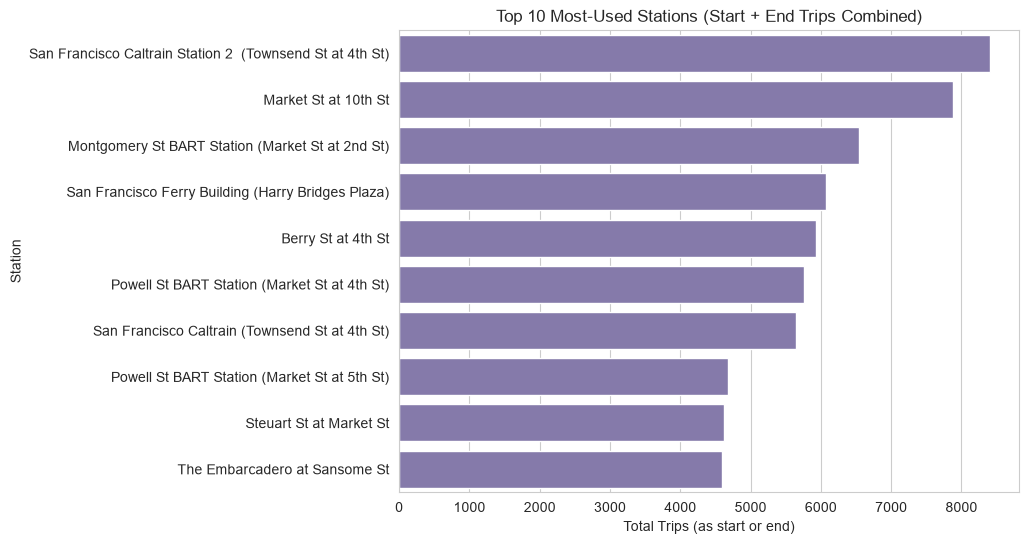

,Station,Total Trips
Rank,,
1,San Francisco Caltrain Station 2 (Townsend St...,8401
2,Market St at 10th St,7877
3,Montgomery St BART Station (Market St at 2nd St),6542
4,San Francisco Ferry Building (Harry Bridges Pl...,6078
5,Berry St at 4th St,5924
6,Powell St BART Station (Market St at 4th St),5757
7,San Francisco Caltrain (Townsend St at 4th St),5650
8,Powell St BART Station (Market St at 5th St),4680
9,Steuart St at Market St,4621


In [23]:
start_counts = df_stations['start_station_name'].value_counts()
end_counts = df_stations['end_station_name'].value_counts()
total_usage = start_counts.add(end_counts, fill_value=0).sort_values(ascending=False)

top_overall = total_usage.head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_overall.values, y=top_overall.index, orient='h', color='#8172B2')
plt.title('Top 10 Most-Used Stations (Start + End Trips Combined)')
plt.xlabel('Total Trips (as start or end)')
plt.ylabel('Station')
plt.show()

top_overall_table = top_overall.reset_index()
top_overall_table.columns = ['Station', 'Total Trips']
top_overall_table.index = range(1, 11)
top_overall_table.index.name = 'Rank'
top_overall_table

**Insight:** Combining both directions, "San Francisco Caltrain Station 2" has the highest combined number of trip starts and ends in the dataset (8,401 total trips), ahead of "Market St at 10th St" (7,877). Note that this number counts **trips**, not unique riders — one frequent commuter could contribute many of these trips. Both transit hubs and central Market St stations dominate this list, regardless of whether a rider is starting or ending there.

##  Map of Stations

We plot every station at its (latitude, longitude), sizing and coloring each point by how many trips it handled (start + end combined), so the busiest hubs stand out visually

In [24]:
start_loc = (df_stations.groupby('start_station_name')[['start_station_latitude', 'start_station_longitude']]
                         .median().rename(columns={'start_station_latitude': 'lat', 'start_station_longitude': 'lon'}))
end_loc = (df_stations.groupby('end_station_name')[['end_station_latitude', 'end_station_longitude']]
                       .median().rename(columns={'end_station_latitude': 'lat', 'end_station_longitude': 'lon'}))
station_locations = pd.concat([start_loc, end_loc])
station_locations = station_locations.groupby(station_locations.index).median()

stations_map_df = station_locations.join(total_usage.rename('usage')).dropna()
stations_map_df.sort_values('usage', ascending=False).head()

,lat,lon,usage
San Francisco Caltrain Station 2 (Townsend St at 4th St),37.776639,-122.395526,8401
Market St at 10th St,37.776619,-122.417385,7877
Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,6542
San Francisco Ferry Building (Harry Bridges Plaza),37.795392,-122.394203,6078
Berry St at 4th St,37.775880,-122.393170,5924


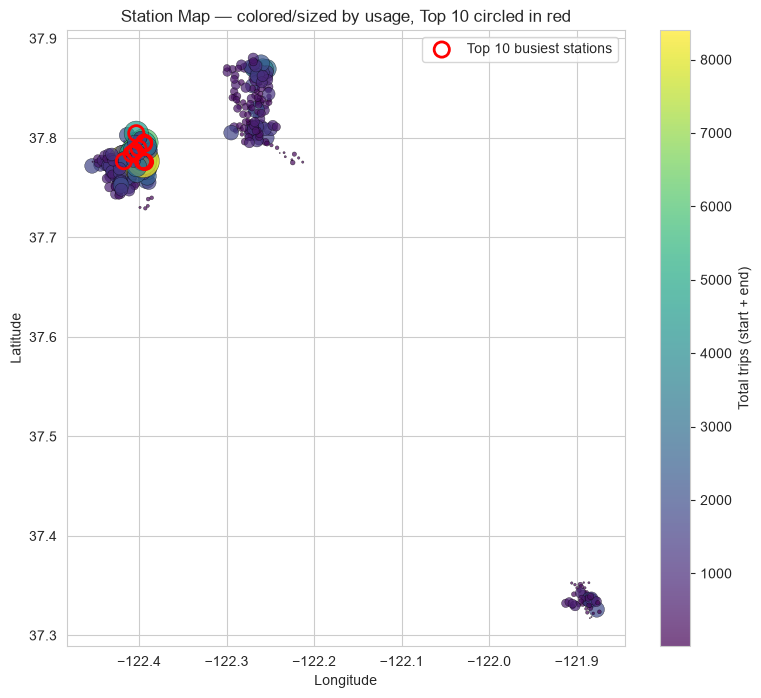

In [ ]:
plt.figure(figsize=(9,8))
scatter = plt.scatter(stations_map_df['lon'], stations_map_df['lat'],
                       s=stations_map_df['usage']/15, c=stations_map_df['usage'],
                       cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.3)
plt.colorbar(scatter, label='Total trips (start + end)')

top10_map = stations_map_df.sort_values('usage', ascending=False).head(10)
plt.scatter(top10_map['lon'], top10_map['lat'], s=120, facecolors='none', edgecolors='red', linewidth=2,
            label='Top 10 busiest stations')

plt.title('Station Map — colored/sized by usage, Top 10 circled in red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

**Insight:** Station usage is concentrated in the central San Francisco area, particularly around the Embarcadero, Market St, and Caltrain corridor. Stations in the outer East Bay and San Jose areas generally show lower usage compared with the main San Francisco cluster.

---
## Summary of Insights

- **Top start stations:** The top 10 start stations account for ~15.5% of all trip starts, led by Market St at 10th St.
- **Top end stations:** Transit stations are even more concentrated as destinations (~17.4% share), led by *SF Caltrain Station 2*, which has more trips ending there than starting there.
- **Top routes:** No single route dominates (~1.5% combined share for the top 10); several top routes are the same station pair used in both directions.
- **Most-used stations overall:** *SF Caltrain Station 2* and *Market St at 10th St* have the highest combined number of trip starts and ends in the dataset (this counts trips, not unique riders).
- **Map:** Station usage is concentrated in the central San Francisco area, particularly around the Embarcadero, Market St, and Caltrain corridor, while outer stations generally show lower usage.